In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [85]:
df = pd.read_excel("customer_churn.xlsx")

print("Excel file loaded successfully!")

Excel file loaded successfully!


In [86]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,TechSupport,OnlineSecurity,Churn
0,CUST001,Male,0,Yes,No,24,One year,Fiber optic,85.42,2050.08,Electronic check,No,No,No
1,CUST002,Female,0,No,No,5,Month-to-month,DSL,61.35,337.84,Bank transfer,No,Yes,Yes
2,CUST003,Male,1,Yes,Yes,48,Two year,Fiber optic,94.18,4564.92,Credit card,Yes,Yes,No
3,CUST004,Female,0,No,No,8,Month-to-month,Fiber optic,76.83,637.41,Electronic check,No,No,Yes
4,CUST005,Male,0,Yes,No,36,One year,DSL,67.21,2464.75,Bank transfer,Yes,No,No


In [87]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100
Number of columns: 14


In [88]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'Contract', 'InternetService', 'MonthlyCharges', 'TotalCharges', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'Churn']


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       100 non-null    object 
 1   Gender           100 non-null    object 
 2   SeniorCitizen    100 non-null    int64  
 3   Partner          100 non-null    object 
 4   Dependents       100 non-null    object 
 5   Tenure           100 non-null    int64  
 6   Contract         100 non-null    object 
 7   InternetService  100 non-null    object 
 8   MonthlyCharges   100 non-null    float64
 9   TotalCharges     100 non-null    float64
 10  PaymentMethod    100 non-null    object 
 11  TechSupport      100 non-null    object 
 12  OnlineSecurity   100 non-null    object 
 13  Churn            100 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 11.1+ KB


In [90]:
df.isnull().sum()


CustomerID         0
Gender             0
SeniorCitizen      0
Partner            0
Dependents         0
Tenure             0
Contract           0
InternetService    0
MonthlyCharges     0
TotalCharges       0
PaymentMethod      0
TechSupport        0
OnlineSecurity     0
Churn              0
dtype: int64

In [91]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [92]:
print("Duplicate Customer IDs:", df["CustomerID"].duplicated().sum())

Duplicate Customer IDs: 0


In [93]:
print(df["Churn"].value_counts())

Churn
No     59
Yes    41
Name: count, dtype: int64


In [94]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     59.0
Yes    41.0
Name: proportion, dtype: float64


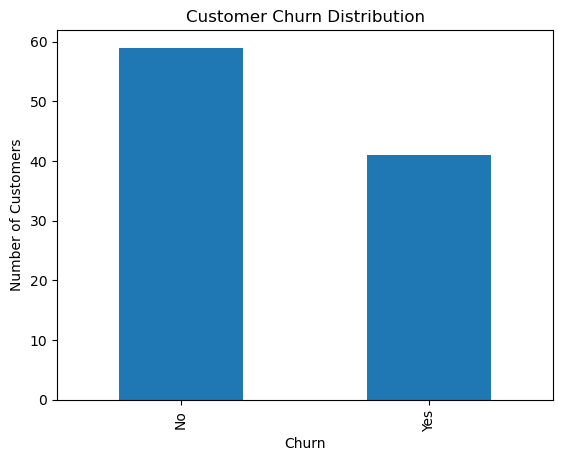

In [95]:
df["Churn"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribution"
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [96]:
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,100.000000,100.000000,100.000000,100.000000
mean,0.200000,30.430000,79.212700,2355.288100
std,0.402015,20.239603,19.071936,1704.818479
min,0.000000,2.000000,29.740000,59.480000
25%,0.000000,11.750000,63.182500,1045.315000
50%,0.000000,28.500000,83.460000,1941.800000
75%,0.000000,47.250000,94.595000,2986.282500
max,1.000000,71.000000,111.260000,6650.220000


In [97]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns.tolist())

['CustomerID', 'Gender', 'Partner', 'Dependents', 'Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'Churn']


In [98]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2.380952,97.619048
One year,100.000000,0.000000
Two year,100.000000,0.000000


In [99]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,87.804878,12.195122
Fiber optic,39.285714,60.714286
No,33.333333,66.666667


In [100]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer,96.428571,3.571429
Credit card,100.000000,0.000000
Electronic check,2.564103,97.435897
Mailed check,60.000000,40.000000


In [101]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     44.118644
Yes    10.731707
Name: Tenure, dtype: float64

In [102]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     72.517119
Yes    88.847805
Name: MonthlyCharges, dtype: float64

In [103]:
data = df.copy()

data.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,TechSupport,OnlineSecurity,Churn
0,CUST001,Male,0,Yes,No,24,One year,Fiber optic,85.42,2050.08,Electronic check,No,No,No
1,CUST002,Female,0,No,No,5,Month-to-month,DSL,61.35,337.84,Bank transfer,No,Yes,Yes
2,CUST003,Male,1,Yes,Yes,48,Two year,Fiber optic,94.18,4564.92,Credit card,Yes,Yes,No
3,CUST004,Female,0,No,No,8,Month-to-month,Fiber optic,76.83,637.41,Electronic check,No,No,Yes
4,CUST005,Male,0,Yes,No,36,One year,DSL,67.21,2464.75,Bank transfer,Yes,No,No


In [104]:
data = data.drop("CustomerID", axis=1)

data.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,TechSupport,OnlineSecurity,Churn
0,Male,0,Yes,No,24,One year,Fiber optic,85.42,2050.08,Electronic check,No,No,No
1,Female,0,No,No,5,Month-to-month,DSL,61.35,337.84,Bank transfer,No,Yes,Yes
2,Male,1,Yes,Yes,48,Two year,Fiber optic,94.18,4564.92,Credit card,Yes,Yes,No
3,Female,0,No,No,8,Month-to-month,Fiber optic,76.83,637.41,Electronic check,No,No,Yes
4,Male,0,Yes,No,36,One year,DSL,67.21,2464.75,Bank transfer,Yes,No,No


In [105]:
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

data["Churn"].head()

0    0
1    1
2    0
3    1
4    0
Name: Churn, dtype: int64

In [106]:
data = pd.get_dummies(
    data,
    drop_first=True
)

data.head()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,TechSupport_Yes,OnlineSecurity_Yes
0,0,24,85.42,2050.08,0,True,True,False,True,False,True,False,False,True,False,False,False
1,0,5,61.35,337.84,1,False,False,False,False,False,False,False,False,False,False,False,True
2,1,48,94.18,4564.92,0,True,True,True,False,True,True,False,True,False,False,True,True
3,0,8,76.83,637.41,1,False,False,False,False,False,True,False,False,True,False,False,False
4,0,36,67.21,2464.75,0,True,True,False,True,False,False,False,False,False,False,True,False


In [107]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

data.info()

Rows: 100
Columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SeniorCitizen                   100 non-null    int64  
 1   Tenure                          100 non-null    int64  
 2   MonthlyCharges                  100 non-null    float64
 3   TotalCharges                    100 non-null    float64
 4   Churn                           100 non-null    int64  
 5   Gender_Male                     100 non-null    bool   
 6   Partner_Yes                     100 non-null    bool   
 7   Dependents_Yes                  100 non-null    bool   
 8   Contract_One year               100 non-null    bool   
 9   Contract_Two year               100 non-null    bool   
 10  InternetService_Fiber optic     100 non-null    bool   
 11  InternetService_No              100 non-null    bool   
 12  PaymentMethod_C

In [108]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 16)
y shape: (100,)


In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 80
Testing records: 20


In [110]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [111]:
#logistic regration
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [112]:
#Make predictions
logistic_pred = logistic_model.predict(X_test_scaled)


logistic_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]


print("Predictions created successfully!")

Predictions created successfully!


In [113]:
#Evaluate the model
accuracy = accuracy_score(y_test, logistic_pred)
precision = precision_score(y_test, logistic_pred, zero_division=0)
recall = recall_score(y_test, logistic_pred, zero_division=0)
f1 = f1_score(y_test, logistic_pred, zero_division=0)


print("Model Performance")
print("-----------------")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Model Performance
-----------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [114]:
#Classification report
print(classification_report(
    y_test,
    logistic_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [115]:
#Confusion matrix
cm = confusion_matrix(y_test, logistic_pred)


print(cm)

[[12  0]
 [ 0  8]]


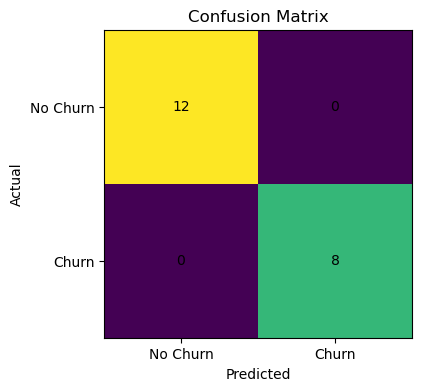

In [116]:
#Optional visualization:

plt.figure(figsize=(5, 4))


plt.imshow(cm)


plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])


for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")


plt.show()

In [117]:
#Random Forest

#This is important because we'll compare it with Logistic Regression.

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)


random_forest.fit(X_train, y_train)


print("Random Forest trained successfully!")

Random Forest trained successfully!


In [118]:
#Random Forest prediction
rf_pred = random_forest.predict(X_test)


rf_probability = random_forest.predict_proba(X_test)[:, 1]

In [119]:
#Random Forest evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)


print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1 Score :", round(rf_f1, 3))

Random Forest Performance
-------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [120]:
#Compare models
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ]
})


comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


In [121]:
#Feature importance

#This is useful for your business explanation and Power BI insights.

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)


feature_importance.head(10)

,Feature,Importance
1,Tenure,0.278439
14,TechSupport_Yes,0.229791
12,PaymentMethod_Electronic check,0.166718
3,TotalCharges,0.140515
7,Contract_One year,0.041897
8,Contract_Two year,0.030889
11,PaymentMethod_Credit card,0.027213
15,OnlineSecurity_Yes,0.025011
2,MonthlyCharges,0.024084
5,Partner_Yes,0.009827


In [122]:
#Final model

#For now, use Random Forest as the final model:

final_model = random_forest


print("Final model selected: Random Forest")

Final model selected: Random Forest


In [123]:
#Test one customer
customer = {
    "Gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "Tenure": 5,
    "Contract": "Month-to-month",
    "InternetService": "Fiber optic",
    "MonthlyCharges": 95.50,
    "TotalCharges": 477.50,
    "PaymentMethod": "Electronic check",
    "TechSupport": "No",
    "OnlineSecurity": "No"
}


customer_df = pd.DataFrame([customer])


customer_encoded = pd.get_dummies(
    customer_df,
    drop_first=True
)


customer_encoded = customer_encoded.reindex(
    columns=X.columns,
    fill_value=0
)


probability = final_model.predict_proba(
    customer_encoded
)[0][1]


prediction = final_model.predict(
    customer_encoded
)[0]


print("Churn Prediction:", "Yes" if prediction == 1 else "No")
print("Churn Probability:", round(probability * 100, 2), "%")

Churn Prediction: Yes
Churn Probability: 82.5 %
